# Feature analysis

2 sections:
1. **Correlation** - heatmap for all numeric features, correlation of each feature with `target_price_kzt`, and pairs of features with high cross-correlation.
2. **Feature importance** - gain from a trained LightGBM. It shows which features actually affect tree splits. Bottom of the list - candidates for deletion.

In [8]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..') / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

TARGET = 'target_price_kzt'
PROCESSED_PATH = Path('..') / 'datasets' / 'processed' / 'ads_model_v1.csv'
df = pd.read_csv(PROCESSED_PATH)
print(f'Rows: {len(df):,}, columns: {len(df.columns)}')
df.head()

Rows: 38,762, columns: 101


,target_price_kzt,area_m2,rooms,lat,lon,year_built,floor_current,floors_total,ceiling_height_m,photo_count,...,universities_nearest_dist_m,air_pm25_cold_night,air_pm25_cold_day,air_pm25_warm_night,air_pm25_warm_day,air_nearest_dist_m,district,house_type,condition,bathroom_type
0,17500000,29.0,1,43.293068,76.829312,2025.0,4.0,5.0,NaN,19,...,5014.3020,56.107334,42.617207,20.620247,15.635147,998.15180,Alatauskiy_r-n,монолитный,свежий ремонт,unknown
1,25000000,42.7,2,43.335155,76.949112,1958.0,2.0,2.0,NaN,7,...,5088.4610,92.624660,59.170303,84.816070,38.219135,595.38590,Turksibskiy_r-n,кирпичный,свежий ремонт,совмещенный
2,22000000,27.0,1,43.325970,77.034988,2025.0,4.0,12.0,NaN,16,...,4005.5967,73.122450,64.940870,47.206547,42.909260,1647.95360,Medeuskiy_r-n,монолитный,свежий ремонт,совмещенный
3,25500000,55.6,2,43.245467,76.806929,2025.0,8.0,12.0,NaN,10,...,2028.2372,36.562794,35.066364,13.290565,14.597521,478.50300,Alatauskiy_r-n,монолитный,свободная планировка,unknown
4,23000000,45.0,1,43.311152,76.896674,2015.0,7.0,7.0,NaN,8,...,5668.7075,93.001170,59.671100,70.230950,35.116665,392.39682,Alatauskiy_r-n,кирпичный,"не новый, но аккуратный ремонт",unknown


## 1.1 Correlation of features with target

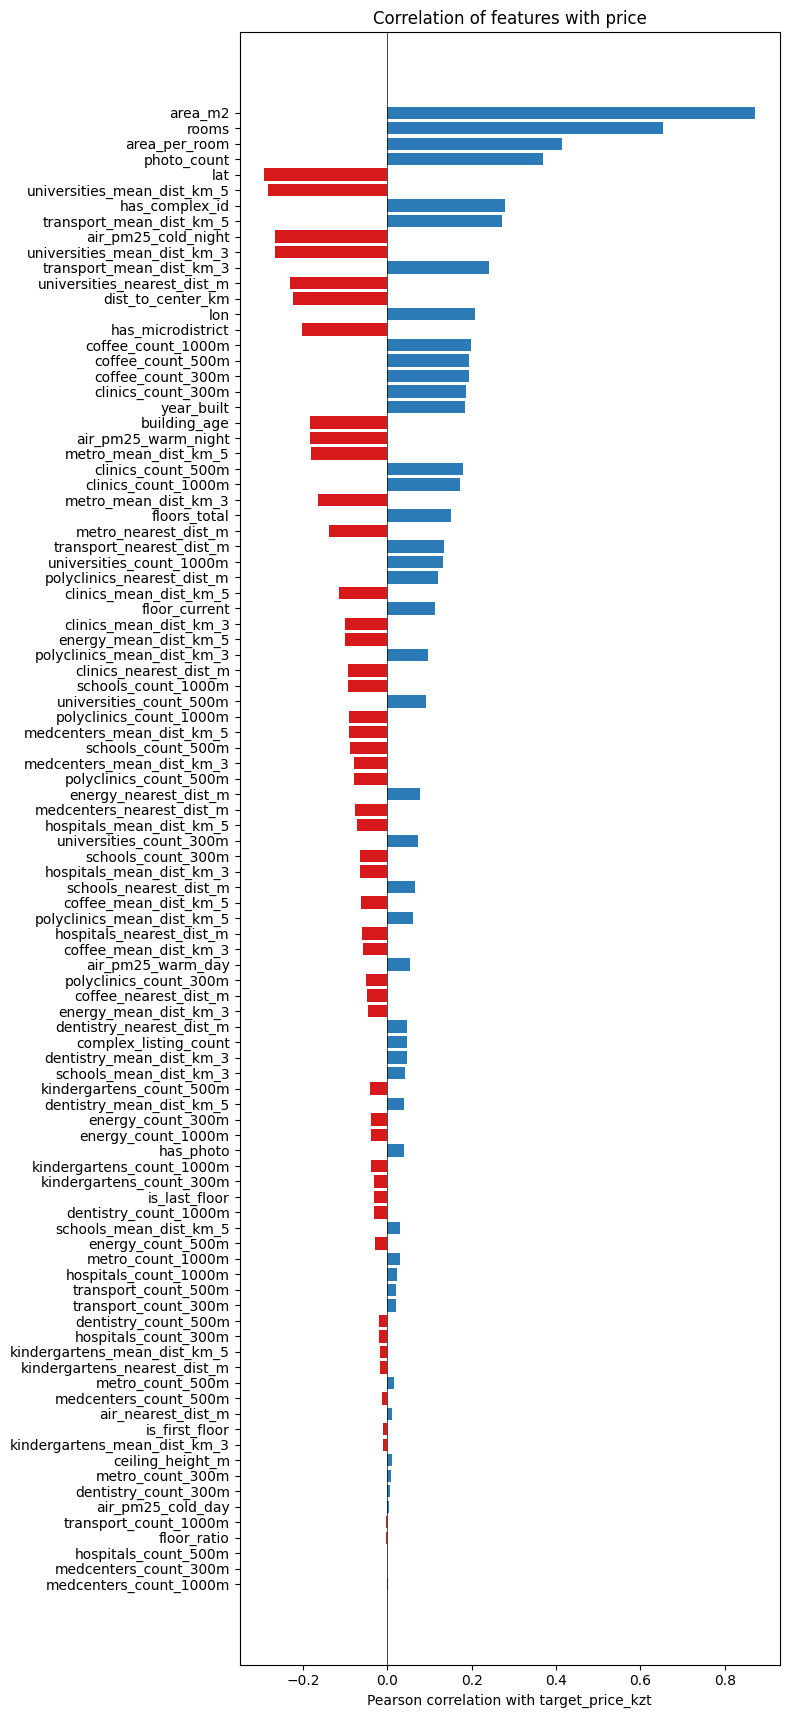

In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_with_target = (
    df[numeric_cols]
    .corr()[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(8, max(8, len(corr_with_target) * 0.18)))
colors = ['#2c7bb6' if v > 0 else '#d7191c' for v in corr_with_target.values[::-1]]
ax.barh(corr_with_target.index[::-1], corr_with_target.values[::-1], color=colors)
ax.set_xlabel('Pearson correlation with target_price_kzt')
ax.set_title('Correlation of features with price')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## 1.2 Heatmap top 20 features with target

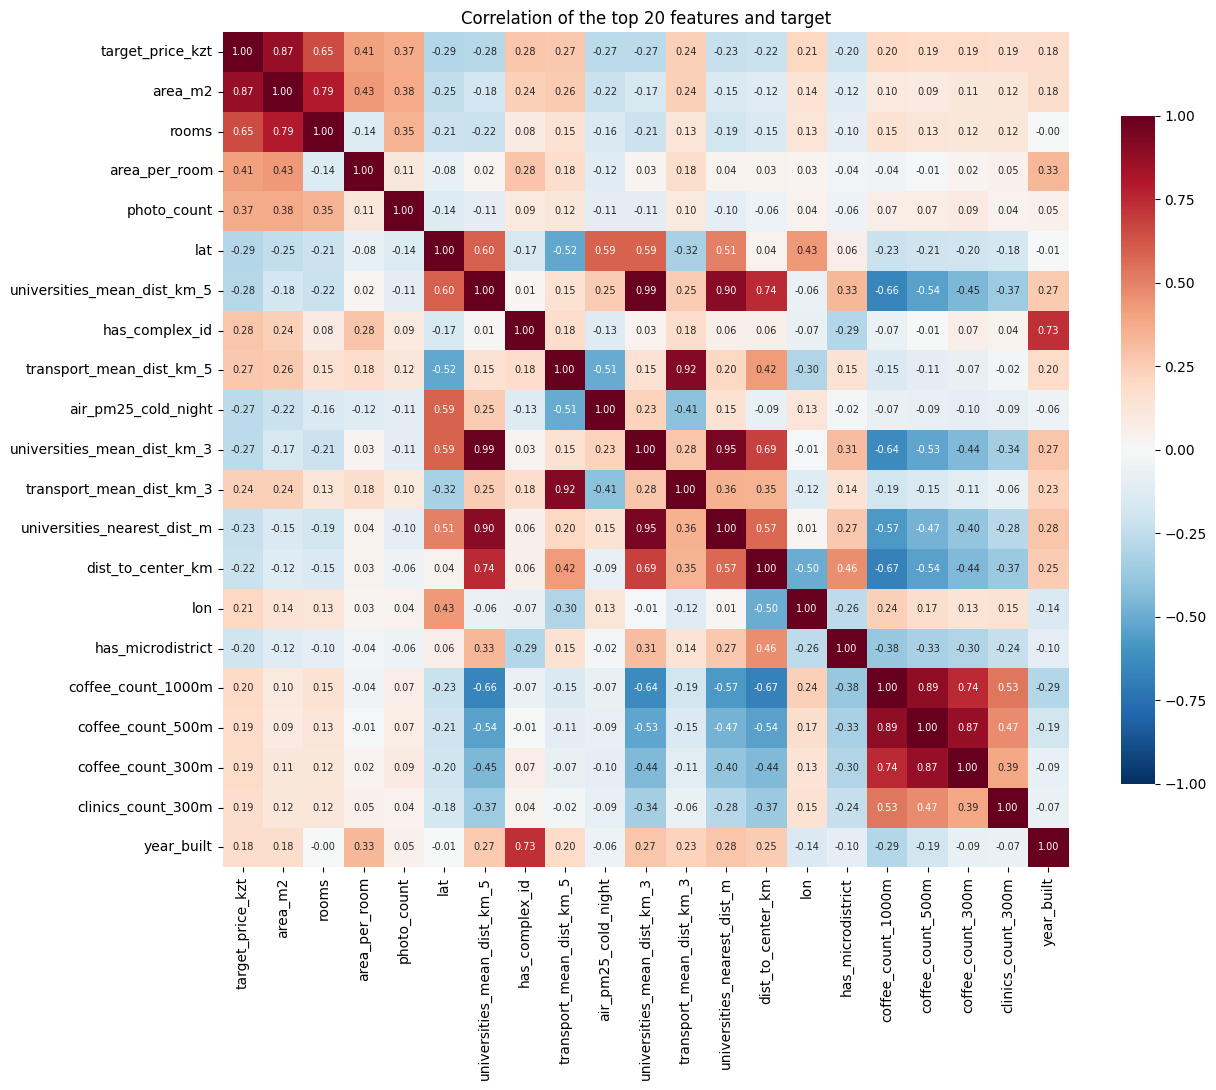

In [10]:
top20 = corr_with_target.abs().head(20).index.tolist()
corr_matrix = df[[TARGET] + top20].corr()

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, ax=ax, annot_kws={'size': 7}, cbar_kws={'shrink': 0.8},
)
ax.set_title('Correlation of the top 20 features and target')
plt.tight_layout()
plt.show()

## 1.3 Pairs of features with high mutual correlation

Boosters handle this, but it can reduce the number of features.

In [11]:
features_only = [c for c in numeric_cols if c != TARGET]
abs_corr = df[features_only].corr().abs()
upper = abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))

high_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_a', 'level_1': 'feature_b', 0: 'abs_corr'})
)
high_pairs = high_pairs[high_pairs['abs_corr'] > 0.9].sort_values('abs_corr', ascending=False)
print(f'Пар с |corr| > 0.9: {len(high_pairs)}')
high_pairs.head(30)

Пар с |corr| > 0.9: 32


,feature_a,feature_b,abs_corr
383,year_built,building_age,1.000000
4064,metro_mean_dist_km_3,metro_mean_dist_km_5,0.994862
2669,dentistry_mean_dist_km_3,dentistry_mean_dist_km_5,0.993705
4065,metro_mean_dist_km_3,metro_nearest_dist_m,0.989494
3857,medcenters_mean_dist_km_3,medcenters_mean_dist_km_5,0.988978
4532,universities_mean_dist_km_3,universities_mean_dist_km_5,0.986535
4370,schools_mean_dist_km_3,schools_mean_dist_km_5,0.986476
4235,polyclinics_mean_dist_km_3,polyclinics_mean_dist_km_5,0.986416
1859,clinics_mean_dist_km_3,clinics_mean_dist_km_5,0.985380
3335,hospitals_mean_dist_km_3,hospitals_mean_dist_km_5,0.976836


## 2. Feature importance from LightGBM

We train the model and look at the gain of each feature (contribution to improving the loss function)

In [12]:
from sklearn.model_selection import train_test_split
from ml_project.air import load_air_catalog
from ml_project.poi import load_poi_catalog
from ml_project.data import load_listings
from ml_project.features import build_processed_dataset
from ml_project.models import create_model
from ml_project.train import stratify_bins
from ml_project.constants import TARGET_COLUMN

listings = load_listings()
poi = load_poi_catalog()
air = load_air_catalog()
processed, schema = build_processed_dataset(listings, poi, air)

train_frame, _ = train_test_split(
    processed, test_size=0.2, random_state=42,
    stratify=stratify_bins(processed[TARGET_COLUMN]),
)

model = create_model('lightgbm')
model.fit(train_frame, schema)

importance = pd.DataFrame({
    'feature': schema.feature_columns,
    'gain': model.model.feature_importances_,
}).sort_values('gain', ascending=False).reset_index(drop=True)
importance.head(20)

,feature,gain
0,area_m2,13344
1,area_per_room,13222
2,photo_count,12432
3,floor_ratio,10997
4,year_built,6122
5,floor_current,5551
6,kindergartens_nearest_dist_m,5414
7,air_nearest_dist_m,5187
8,coffee_nearest_dist_m,5002
9,schools_nearest_dist_m,4963


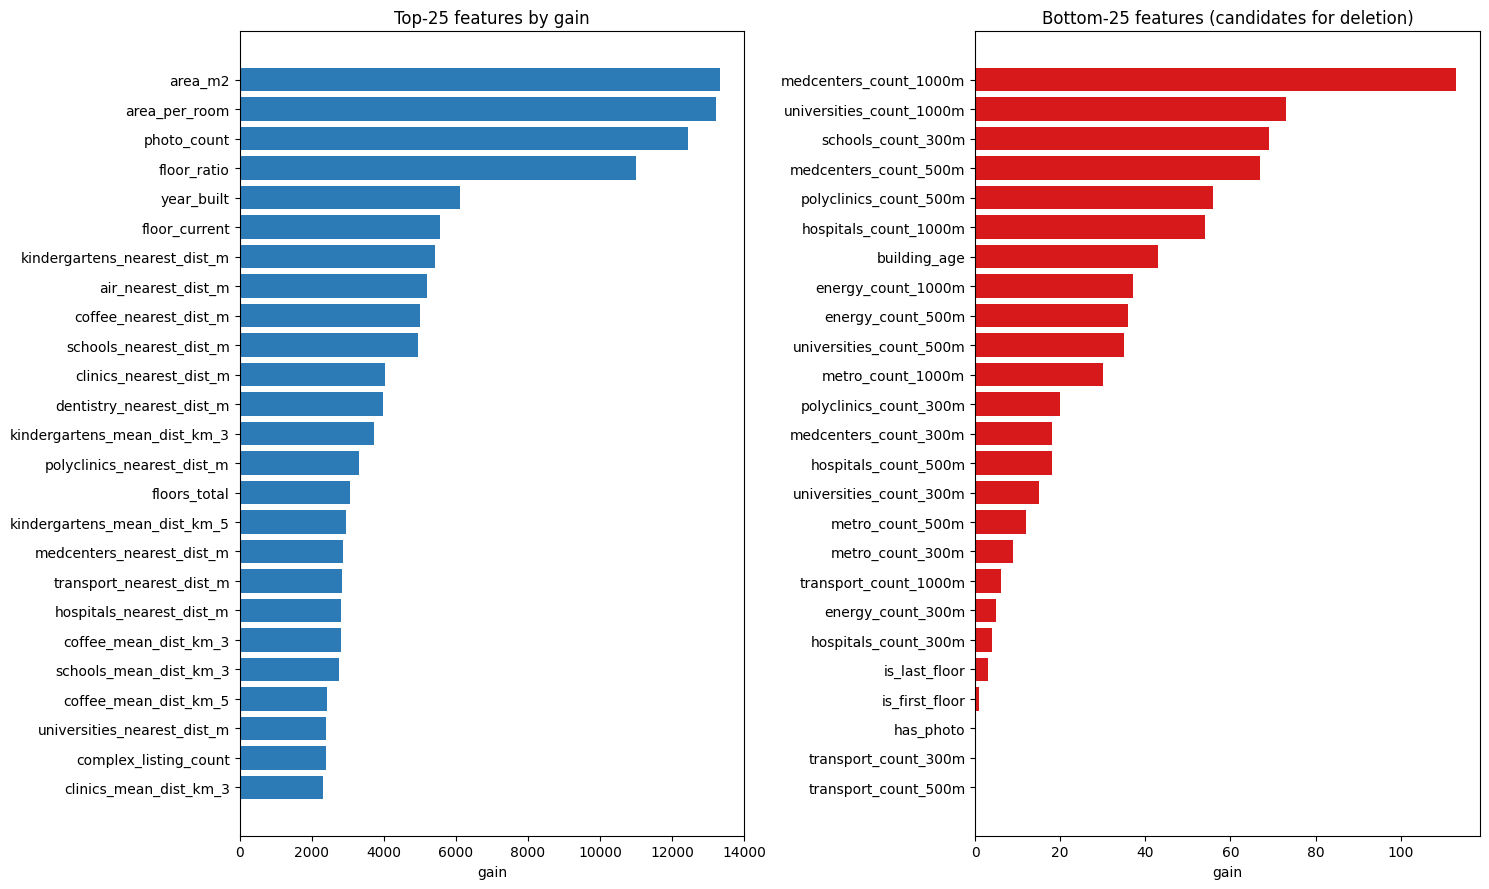

In [13]:
top_n = 25
fig, axes = plt.subplots(1, 2, figsize=(15, 9))

top = importance.head(top_n)
axes[0].barh(top['feature'][::-1], top['gain'][::-1], color='#2c7bb6')
axes[0].set_title(f'Top-{top_n} features by gain')
axes[0].set_xlabel('gain')

bottom = importance.tail(top_n)
axes[1].barh(bottom['feature'][::-1], bottom['gain'][::-1], color='#d7191c')
axes[1].set_title(f'Bottom-{top_n} features (candidates for deletion)')
axes[1].set_xlabel('gain')

plt.tight_layout()
plt.show()

## 2.2 Candidates for deletion

Features with a `gain < 0.1%` of the maximum are almost not used by trees. They can be deleted without loss of quality.

In [14]:
threshold = importance['gain'].max() * 0.001
low_importance = importance[importance['gain'] < threshold]
print(f'Features with gain < 0.1% of the maximum: {len(low_importance)} from {len(importance)}')
print()
print('List:')
for feature in low_importance['feature'].tolist():
    print(f'  - {feature}')

Features with gain < 0.1% of the maximum: 10 from 100

List:
  - metro_count_500m
  - metro_count_300m
  - transport_count_1000m
  - energy_count_300m
  - hospitals_count_300m
  - is_last_floor
  - is_first_floor
  - has_photo
  - transport_count_300m
  - transport_count_500m
